In [11]:
from pathlib import Path
import dask.array as da
import pandas as pd
import anndata as ad
import napari
import numpy as np
from tqdm.auto import tqdm
import json
import seaborn as sns
import matplotlib.pyplot as plt
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']


def timed_compute(volume):

    """
    Compute a lazy Dask array frame-by-frame with progress reporting.

    This function iterates over the leading axis of a Dask array (e.g. time),
    calls `.compute()` on each slice, and stacks the results into a single
    NumPy array. A tqdm progress bar is displayed to indicate progress.

    Parameters
    ----------
    volume : dask.array.Array
        A Dask array with at least one dimension (e.g. shape (T, ...)).
        The function will iterate over the first axis (axis=0).

    Returns
    -------
    numpy.ndarray
        A NumPy array with the same shape as `volume`, but fully realized
        in memory. The dtype is preserved from the Dask array.

    Notes
    -----
    - Each frame is computed independently, which can be helpful for
      monitoring performance and memory use on large arrays.
    - The returned array may be very large if `volume` is large.
      Ensure sufficient memory is available.
    """
    return np.stack([frame.compute() for frame in tqdm(volume, total = len(volume), leave=False)], axis=0)


In [12]:
root_dir = Path('/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/zarr')
# root_dir = Path('/Volumes/OPERA3/Nathan/Z_stack_tests/zarr')
rc_stem = "(3,3)"
store = root_dir / f"{rc_stem}.zarr"

# --- load images and segmentation ---
images = da.from_zarr(str(store / "images" / "0"))   # (T,C,Z,Y,X)
masks  = da.from_zarr(str(store / "labels" / "masks"))  # (T,Z,Y,X)

# --- load tracks (CSV preferred, fallback to AnnData) ---
# tracks_csv = root_dir / f"{rc_stem}_tracks.csv"
# if tracks_csv.exists():
#     tracks = pd.read_csv(tracks_csv)
# else:
adata = ad.read_zarr(str(store / "tables" / "quantified_tracks"))
tracks = adata.obs.reset_index(drop=True)

print("images:", images.shape)
print("masks:", masks.shape)
print("tracks:", tracks.shape)


images: (97, 2, 25, 7992, 7992)
masks: (97, 25, 7992, 7992)
tracks: (1859520, 10)


In [13]:
images

dask.array<from-zarr, shape=(97, 2, 25, 7992, 7992), dtype=uint16, chunksize=(1, 1, 16, 512, 512), chunktype=numpy.ndarray>

In [14]:
%%time
# full time axis
all_t = np.arange(tracks['t'].min(), tracks['t'].max() + 1, dtype=int)

# reindex each track-z group to break lines on missing timepoints
def expand_group(g):
    out = g.set_index('t').reindex(all_t)
    out['ID'] = g.name[0]
    out['z']  = g.name[1]
    return out.reset_index().rename(columns={'index': 't'})

tracks = (tracks
    .groupby(['ID', 'z'], group_keys=False)
    .apply(expand_group)
)

CPU times: user 39.8 s, sys: 477 ms, total: 40.2 s
Wall time: 40.2 s


<timed exec>:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


# Process Mtb signals

### Add scale to df

In [15]:
px_size_um = 0.14949
px_area_um2 = px_size_um ** 2
frame_rate = 0.5
# add new column in µm²
tracks['Mtb Area (µm)'] = tracks['mtb_area_px'] * px_area_um2
tracks['Time (hours)'] = tracks['t'] * frame_rate

In [16]:
df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/3.3.max_proj_sc_df.update.pkl')

In [7]:
tracks

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours)
0,0,1,0,866.0,6511.0,18375.0,0.0,817.0,3.0,3.0,0.0,0.0
1,1,1,0,858.0,6514.0,16950.0,0.0,181.0,3.0,3.0,0.0,0.5
2,2,1,0,844.0,6532.0,13600.0,0.0,213.0,3.0,3.0,0.0,1.0
3,3,1,0,846.0,6536.0,16650.0,0.0,380.0,3.0,3.0,0.0,1.5
4,4,1,0,841.0,6559.0,16300.0,0.0,437.0,3.0,3.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
92,92,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0
93,93,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.5
94,94,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0
95,95,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.5


In [8]:
df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times,mtb_origin
0,0,1,24,866.0,6511.0,18900.0,0.0,817.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.000000,1.000000,"[1.92, 3.84, 7.68, 15.36]","[1.0, 0.5, 8.0]",Transfer
1,0,6,24,525.0,4880.0,17250.0,0.0,755.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.000000,0.804189,NaN,NaN,None
2,0,9,22,7490.0,1929.0,18000.0,0.0,64.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.144179,0.247361,NaN,NaN,None
3,0,10,22,4221.0,542.0,47050.0,101.0,1009.0,3.0,3.0,2.257073,0.0,2.257073,0.0,2.266954,0.916470,NaN,NaN,None
4,0,11,24,4548.0,823.0,23025.0,123.0,442.0,3.0,3.0,2.748713,0.0,2.748713,0.0,2.484378,0.810000,"[2.363652037311596, 4.727304074623192, 9.45460...","[5.0, 16.0, -1.0, -5.5]",Transfer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130363,96,8595,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,11.374755,48.0,11.374755,0.646219,NaN,NaN,None
130364,96,8597,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,3.195658,48.0,3.201369,0.584448,NaN,NaN,None
130365,96,8600,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.938153,"[1.92, 3.84, 7.68]","[-2.5, -16.0]",None
130366,96,8617,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.850124,"[1.92, 3.84]",[-5.5],None


# Plot all dt with ID colour code

/tmp/ipykernel_225084/1894280801.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_225084/1894280801.py:24: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


Text(0.5, 1.0, 'Doubling times over full 25µm max projection')

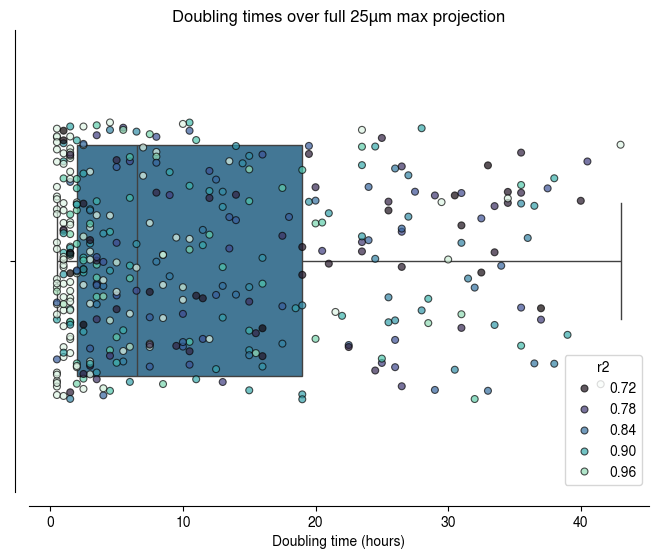

In [9]:
subset_df = (
    df.drop_duplicates(subset="ID")
      .dropna(subset=["Doubling Times"])
      .explode("Doubling Times")
)

subset_df = subset_df[
    # subset_df[id_key].isin(largest_IDs) &
    (subset_df["Doubling Times"] > 0) &
    (subset_df["r2"] >= 0.7)
].copy()

plt.figure(figsize=(8,6))
ax = sns.boxplot(
    data=subset_df,
    x="Doubling Times",
    whis=[0, 100],
    width=0.5,
    color=None,
    palette="mako"
)

# Overlay per-ID scatter, each ID with its own color + legend
sns.stripplot(
    data=subset_df,
    x="Doubling Times",
    hue="r2",              # categorical grouping
    palette="mako",           # or "tab10" for 10 distinct colors
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.3,
    dodge=False
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")

plt.title('Doubling times over full 25µm max projection')

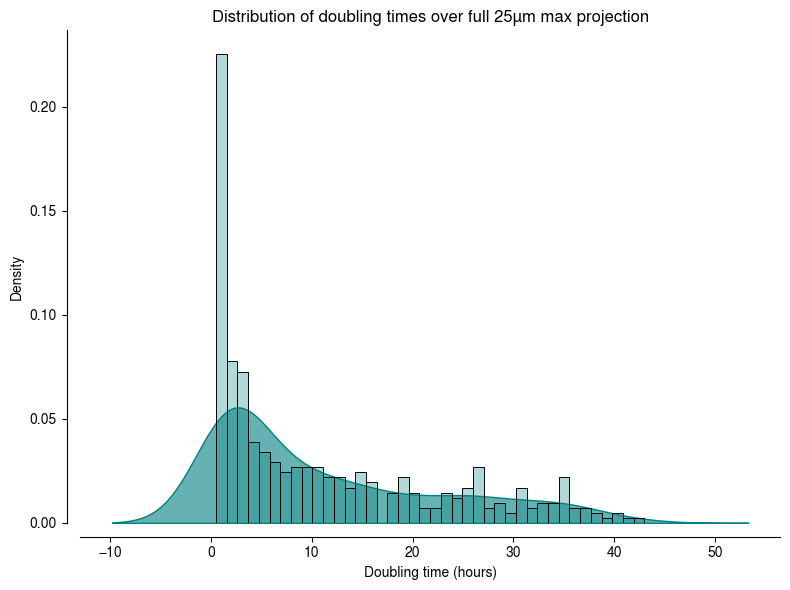

In [10]:
plt.figure(figsize=(8,6))

# Smooth KDE distribution
sns.kdeplot(
    data=subset_df,
    x="Doubling Times",
    fill=True,
    common_norm=False,
    alpha=0.6,
    color="teal"  # or use a palette if you want groups
)

# Optionally overlay a histogram
sns.histplot(
    data=subset_df,
    x="Doubling Times",
    bins=40,
    color="teal",
    alpha=0.3,
    stat="density"   # normalize so it overlays with KDE
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")
plt.title("Distribution of doubling times over full 25µm max projection")
plt.tight_layout()
plt.show()


### Load OG df

In [11]:
og_df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl')

In [12]:
og_df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.000000,0.0,4649.351562,2080.574775,NaN,0.0,0.0,107.845200,755.241882,...,NaN,NaN,NaN,NaN,None,None,None,1.0,0,NaN
1,0.5,0.000000,0.0,4973.001953,2080.574775,NaN,0.0,0.0,113.264671,764.392212,...,0.0,NaN,NaN,NaN,None,None,None,1.0,1,NaN
2,1.0,0.000000,0.0,4687.857910,2080.574775,NaN,0.0,0.0,116.562256,767.332825,...,0.0,NaN,NaN,NaN,None,None,None,1.0,2,NaN
3,1.5,0.000000,0.0,4209.064453,2080.574775,NaN,0.0,0.0,111.890106,758.421265,...,0.0,NaN,NaN,NaN,None,None,None,1.0,3,NaN
4,2.0,0.000000,0.0,4061.855225,2080.574775,False,0.0,0.0,114.113556,759.828735,...,0.0,NaN,0.0,0.000000,None,None,None,1.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604938,74.5,1.318559,0.0,465.719601,-259.532690,1.0,0.0,0.0,199.740707,530.029724,...,NaN,3.754542,70.0,3.831754,NaN,None,None,0.92,149,8.0
604939,75.0,0.000000,0.0,392.506040,-259.532690,0.0,0.0,0.0,200.346191,529.733398,...,NaN,2.771209,70.5,3.993013,NaN,None,None,0.92,150,8.0
604940,75.5,0.000000,0.0,410.295415,-259.532690,0.0,0.0,0.0,200.246902,528.299072,...,NaN,3.285224,71.0,4.152034,NaN,None,None,0.92,151,8.0
604941,76.0,0.000000,0.0,463.708240,-259.532690,0.0,0.0,0.0,200.559875,529.950134,...,NaN,5.251889,71.5,4.311997,NaN,None,None,0.92,152,8.0


In [13]:
subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)

subset_og_df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
405,0.0,46.797680,136.772588,660.776979,-68.386294,NaN,1.0,1.0,519.922607,876.779602,...,NaN,NaN,NaN,NaN,Growth,"[50.6, 101.2]",28.0,0.97,0,NaN
8714,11.0,34.036708,140.325993,479.262769,952.290318,NaN,1.0,1.0,682.521484,528.266724,...,NaN,NaN,NaN,NaN,Growth,"[44.1, 88.2]",32.0,0.95,22,NaN
18973,0.0,9.810975,23.443537,769.569275,-185.492235,NaN,1.0,1.0,474.159943,709.874268,...,NaN,NaN,NaN,NaN,Growth,"[8.5, 17.0, 34.0]",29.0,0.91,0,NaN
18973,0.0,9.810975,23.443537,769.569275,-185.492235,NaN,1.0,1.0,474.159943,709.874268,...,NaN,NaN,NaN,NaN,Growth,"[8.5, 17.0, 34.0]",33.0,0.91,0,NaN
22011,0.0,51.736691,109.038147,500.292664,-184.799433,NaN,1.0,1.0,140.723206,642.738159,...,NaN,NaN,NaN,NaN,Growth,"[65.7, 131.4]",38.5,0.97,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040123,3.0,6.145827,24.762096,1283.963844,-405.602238,NaN,1.0,1.0,465.167297,314.734009,...,NaN,NaN,NaN,NaN,Growth,"[6.9, 13.8, 27.6]",25.0,0.98,3,NaN
1040123,3.0,6.145827,24.762096,1283.963844,-405.602238,NaN,1.0,1.0,465.167297,314.734009,...,NaN,NaN,NaN,NaN,Growth,"[6.9, 13.8, 27.6]",33.0,0.98,3,NaN
1091757,4.0,2.346589,32.829891,1537.216616,-899.078630,NaN,1.0,1.0,1085.988037,704.828186,...,NaN,NaN,NaN,NaN,Growth,"[2.1, 4.2, 8.4, 16.8]",17.0,0.96,4,NaN
1091757,4.0,2.346589,32.829891,1537.216616,-899.078630,NaN,1.0,1.0,1085.988037,704.828186,...,NaN,NaN,NaN,NaN,Growth,"[2.1, 4.2, 8.4, 16.8]",15.0,0.96,4,NaN


/tmp/ipykernel_225084/1962237016.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_225084/1962237016.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_225084/1962237016.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


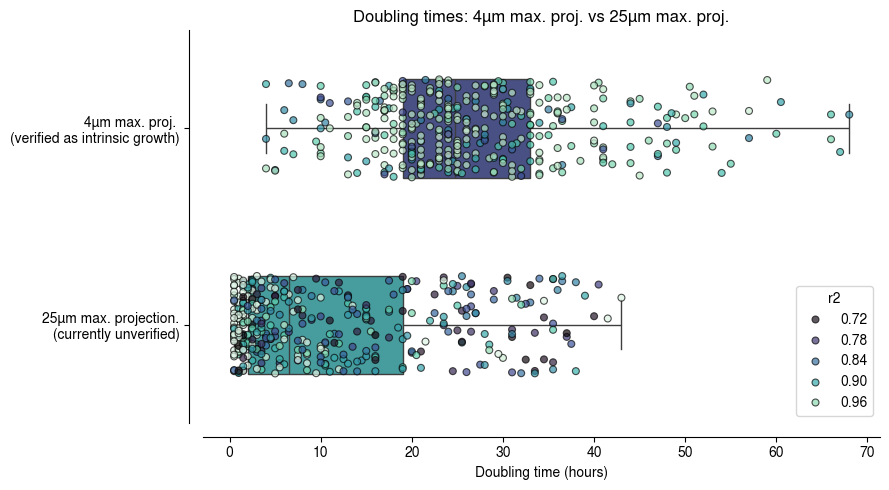

In [14]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel("")
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.")
# ax.legend(title="r²", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()


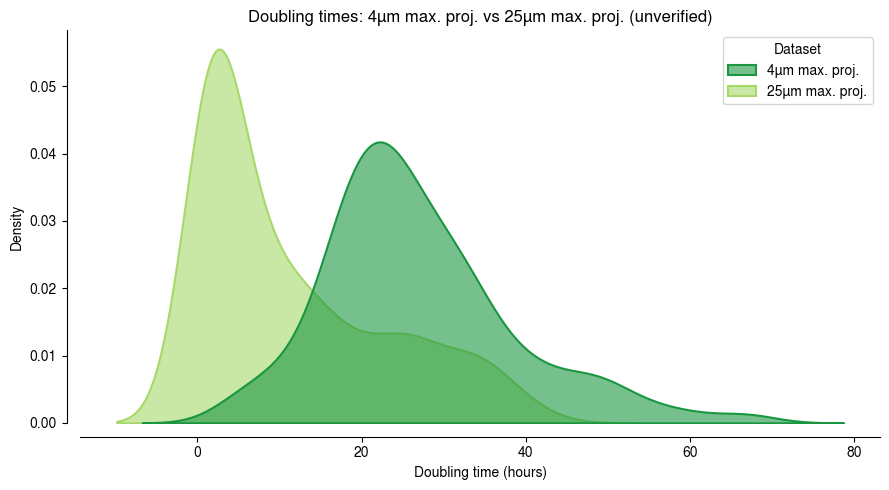

In [15]:
plt.figure(figsize=(9, 5))

# KDEs stacked along Y (ridge style)
sns.kdeplot(
    data=combo,
    x="Doubling Times",
    # y="Dataset",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.6,
    linewidth=1.5,
    palette=expanded_piyg[:2]  # two colors for the datasets
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")

plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj. (unverified)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_225084/3447116030.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_225084/3447116030.py:30: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_225084/3447116030.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


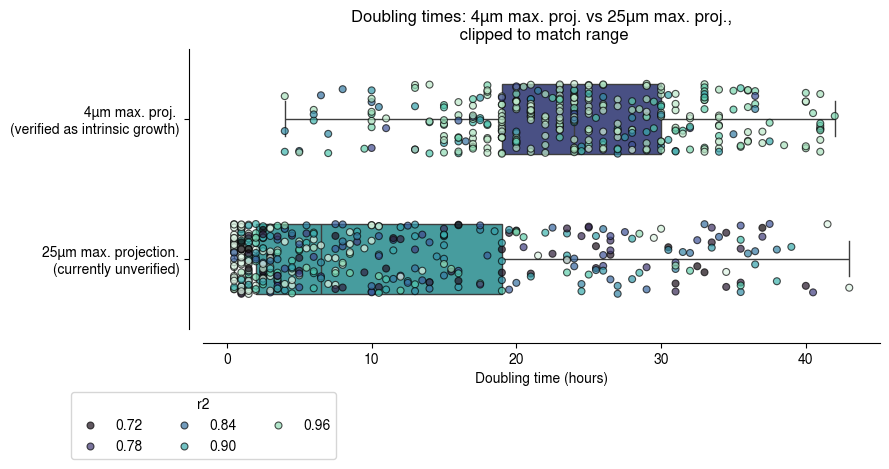

In [16]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\n clipped to match range")
ax.legend(
    bbox_to_anchor=(0., -0.2),
    loc="upper center",
    ncol=3,   # spread across columns
    frameon=True, 
    title='r2'
)
plt.tight_layout()


/tmp/ipykernel_225084/1527149221.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_225084/1527149221.py:47: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_225084/1527149221.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


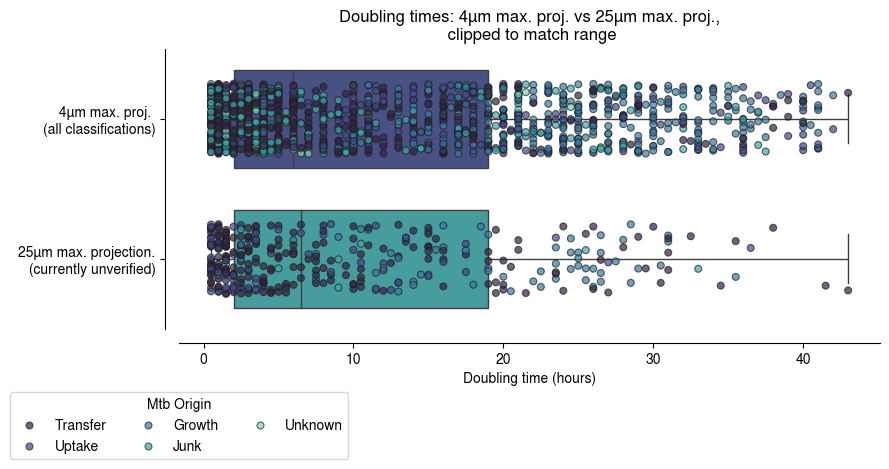

In [17]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
# a['mtb_origin'] = 'Unknown'


subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        # & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)


b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.7,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='mtb_origin'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_yticklabels([
    " 4µm max. proj. \n(all classifications)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\n clipped to match range")
ax.legend(
    bbox_to_anchor=(0., -0.2),
    loc="upper center",
    ncol=3,   # spread across columns
    frameon=True, 
    title='Mtb Origin'
)
plt.tight_layout()


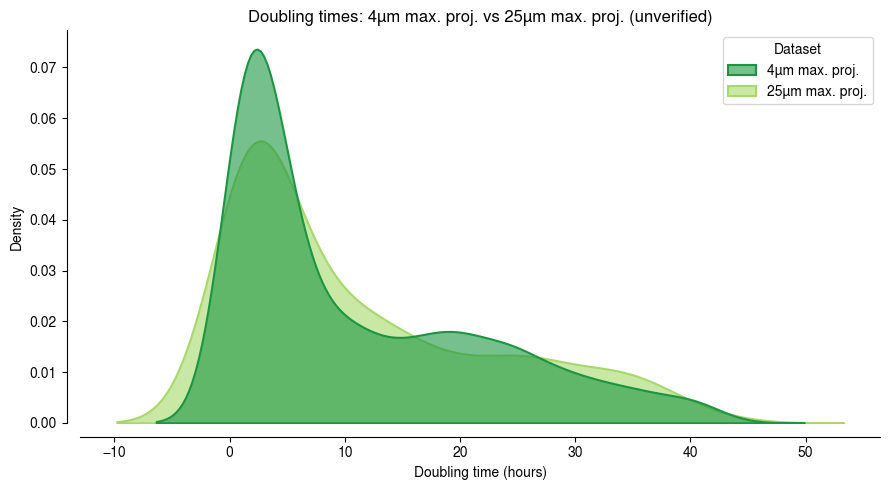

In [18]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
a['mtb_origin'] = 'Unknown'


subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        # & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)


b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))

# KDEs stacked along Y (ridge style)
sns.kdeplot(
    data=combo,
    x="Doubling Times",
    # y="Dataset",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.6,
    linewidth=1.5,
    palette=expanded_piyg[:2]  # two colors for the datasets
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")

plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj. (unverified)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_225084/193804231.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_225084/193804231.py:34: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_225084/193804231.py:46: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_225084/193804231.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


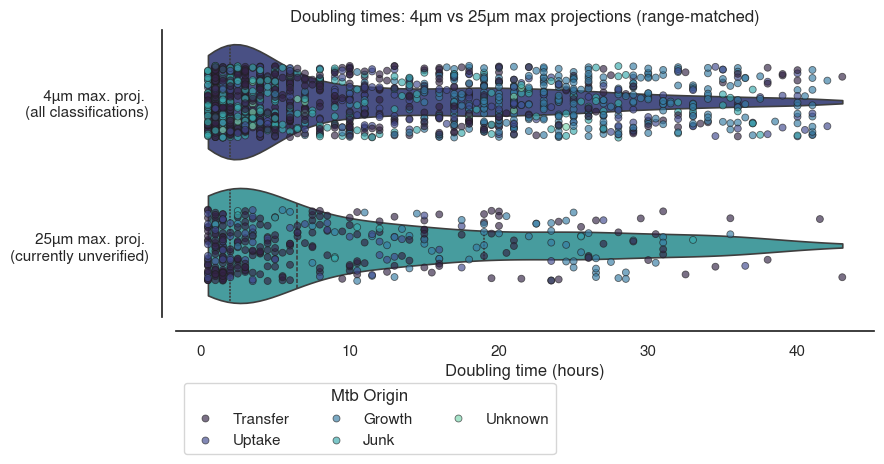

In [19]:
# Prepare datasets
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
# a["mtb_origin"] = "Unknown"

subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)

b = subset_og_df.copy().assign(Dataset="4µm max. proj.")
b = b[b["Doubling Times"] <= a["Doubling Times"].max()]

combo = pd.concat([a, b], ignore_index=True)
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

# Plot — horizontal violins + jittered points
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

plt.figure(figsize=(9, 5))
ax = sns.violinplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue=None,
    cut=0,
    inner="quartile",
    scale="width",
    linewidth=1.2,
    palette="mako"
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue="mtb_origin",
    palette='mako',
    alpha=0.65,
    edgecolor="gray",
    linewidth=0.6,
    jitter=0.25,
    dodge=False
)

# Legend for mtb_origin only
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(
        handles=handles[-combo["mtb_origin"].nunique():],
        labels=labels[-combo["mtb_origin"].nunique():],
        title="Mtb Origin",
        bbox_to_anchor=(0.0, -0.2),
        loc="upper left",
        ncol=3,
        frameon=True,
    )

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel("")
ax.set_yticklabels([
    " 4µm max. proj. \n(all classifications)",
    "25µm max. proj. \n(currently unverified)"
])
ax.set_title("Doubling times: 4µm vs 25µm max projections (range-matched)")
plt.tight_layout()


# Manually check the doubling times

In [20]:
df['mtb_origin'].unique()

array(['Transfer', None, 'Uptake', 'Growth', 'Junk'], dtype=object)

In [21]:
# Sort by doubling time
subset_df_sorted = subset_df.sort_values("Doubling Times")

# Extract IDs in sorted order (keep first occurrence only)
ordered_ids = subset_df_sorted.drop_duplicates("ID")["ID"].tolist()
print(len(ordered_ids))
# Iterate
for ID in ordered_ids:
    df_id = subset_df[subset_df["ID"] == ID]
    dt_val = subset_df_sorted.loc[subset_df_sorted["ID"] == ID, "Doubling Times"].iloc[0]
    print(f"ID {ID}, DT={dt_val}")


218
ID 1307, DT=0.5
ID 3077, DT=0.5
ID 254, DT=0.5
ID 2287, DT=0.5
ID 285, DT=0.5
ID 5215, DT=0.5
ID 2289, DT=0.5
ID 1928, DT=0.5
ID 2426, DT=0.5
ID 761, DT=0.5
ID 2763, DT=0.5
ID 2901, DT=0.5
ID 3494, DT=0.5
ID 4853, DT=0.5
ID 6461, DT=0.5
ID 3105, DT=0.5
ID 1806, DT=0.5
ID 1, DT=0.5
ID 7078, DT=0.5
ID 7697, DT=0.5
ID 1366, DT=0.5
ID 7230, DT=0.5
ID 1919, DT=0.5
ID 1312, DT=1.0
ID 2807, DT=1.0
ID 667, DT=1.0
ID 782, DT=1.0
ID 1456, DT=1.0
ID 1492, DT=1.0
ID 2112, DT=1.0
ID 1499, DT=1.0
ID 2032, DT=1.0
ID 3029, DT=1.0
ID 6216, DT=1.0
ID 6277, DT=1.0
ID 364, DT=1.0
ID 6470, DT=1.0
ID 7598, DT=1.0
ID 3547, DT=1.0
ID 8055, DT=1.0
ID 3190, DT=1.5
ID 2978, DT=1.5
ID 2609, DT=1.5
ID 2512, DT=1.5
ID 3961, DT=1.5
ID 4004, DT=1.5
ID 4091, DT=1.5
ID 4099, DT=1.5
ID 4351, DT=1.5
ID 5612, DT=1.5
ID 2166, DT=1.5
ID 1296, DT=1.5
ID 1135, DT=1.5
ID 5969, DT=2.0
ID 6014, DT=2.0
ID 3596, DT=2.0
ID 3591, DT=2.0
ID 8562, DT=2.0
ID 7380, DT=2.0
ID 3241, DT=2.5
ID 4824, DT=2.5
ID 573, DT=2.5
ID 4849, DT=2.

In [22]:
# Filter for rows where mtb_origin is None
subset_df_filtered = subset_df[subset_df["mtb_origin"].isna()]

# Sort by doubling time
subset_df_sorted = subset_df_filtered.sort_values("Doubling Times")

# Extract IDs in sorted order (first occurrence only)
ordered_ids = subset_df_sorted.drop_duplicates("ID")["ID"].tolist()
print(len(ordered_ids))

# Iterate and print
for ID in ordered_ids:
    df_id = subset_df_filtered[subset_df_filtered["ID"] == ID]
    dt_val = subset_df_sorted.loc[subset_df_sorted["ID"] == ID, "Doubling Times"].iloc[0]
    print(f"ID {ID}, DT={dt_val}")


24
ID 1331, DT=31.5
ID 5481, DT=32.0
ID 3101, DT=32.0
ID 43, DT=32.5
ID 1295, DT=33.0
ID 1842, DT=33.5
ID 1008, DT=33.5
ID 4072, DT=33.5
ID 5239, DT=34.0
ID 500, DT=34.5
ID 2410, DT=34.5
ID 2312, DT=35.5
ID 2669, DT=35.5
ID 79, DT=35.5
ID 4511, DT=35.5
ID 3564, DT=36.0
ID 2726, DT=36.5
ID 5426, DT=37.0
ID 1792, DT=37.0
ID 173, DT=37.5
ID 960, DT=38.0
ID 1304, DT=39.0
ID 1506, DT=40.0
ID 3660, DT=40.5


In [23]:
napari_tracks = tracks[tracks.z==12][['ID', 't', 'z', 'y', 'x']].dropna().values

### Functions

In [17]:
def highlight_cell(
    cell_ID,
    viewer,
    tracks,
    *,
    scale_factor: float = 1.0,
    napari_scale=None,
    size: int = 300,
    opacity: float = 1.0,
    symbol: str = "o",
    reset_position: bool = True,
):
    """
    Highlight a cell's trajectory in napari.

    Parameters
    ----------
    cell_ID : int
        Cell ID to highlight.
    viewer : napari.viewer.Viewer
        The napari viewer instance.
    tracks : list[Tracklet] | np.ndarray | pd.DataFrame
        Either:
          • a list of Tracklet objects with attrs (ID, t, y, x), or
          • an array/DataFrame with columns ordered as ID T(Z)YX.
    scale_factor : float
        Factor to multiply Y/X coordinates.
    napari_scale : list[float] | None
        Scale metadata for napari.
    size, opacity, symbol, reset_position
        Visual options.

    Returns
    -------
    napari.layers.Points
    """

    import numpy as np
    import pandas as pd

    # --- Case 1: Tracklet objects ---
    if isinstance(tracks, (list, tuple)) and tracks and hasattr(tracks[0], "ID"):
        tr = next(t for t in tracks if t.ID == cell_ID)
        points = np.column_stack([
            np.asarray(tr.t, dtype=float),
            np.asarray(tr.y, dtype=float) * scale_factor,
            np.asarray(tr.x, dtype=float) * scale_factor,
        ])
        has_z = False

    # --- Case 2: Array/DataFrame, schema = ID T(Z)YX ---
    else:
        if isinstance(tracks, pd.DataFrame):
            arr = tracks.to_numpy(dtype=float)
            cols = list(tracks.columns)
            has_z = "z" in cols
        else:
            arr = np.asarray(tracks, dtype=float)
            has_z = arr.shape[1] == 5

        # Filter rows by ID
        arr = arr[arr[:, 0] == float(cell_ID)]

        # Drop NaN rows
        arr = arr[~np.isnan(arr).any(axis=1)]
        if arr.size == 0:
            raise ValueError(f"No valid samples for cell {cell_ID}.")

        if has_z:
            t, z, y, x = arr[:, 1], arr[:, 2], arr[:, 3] * scale_factor, arr[:, 4] * scale_factor
            points = np.column_stack([t, z, y, x])
        else:
            t, y, x = arr[:, 1], arr[:, 2] * scale_factor, arr[:, 3] * scale_factor
            points = np.column_stack([t, y, x])

    # --- Add to napari ---
    layer = viewer.add_points(
        points,
        size=size,
        symbol=symbol,
        face_color="transparent",
        edge_color="white",
        edge_width=0.1,
        name=f"cell {cell_ID}",
        opacity=opacity,
        scale=napari_scale,
    )

    if reset_position:
        step = tuple(int(round(v)) for v in points[0])
        viewer.dims.current_step = step

    return layer

In [18]:
def mark_transfer(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Transfer'
    print(f"ID {ID} marked as 'Transfer'.")

def mark_uptake(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Uptake'
    print(f"ID {ID} marked as 'Uptake'.")

def mark_junk(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Junk'
    print(f"ID {ID} marked as 'Junk'.")

def mark_growth(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Growth'
    print(f"ID {ID} marked as 'Growth'.")

def save_df(viewer):
    df.to_pickle('/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/3.3.max_proj_sc_df.update.pkl')
    print('DataFrame saved out')


In [56]:
# from macrohet import visualise
# colours = visualise.colours.expanded_piyg
colours = [
    '#1a9641',  # First color from sns.color_palette('PiYG')
    '#a6d96a',  # Second color from sns.color_palette('PiYG')
    '#978897',  # Rose Quartz in hexadecimal format
    '#d1d1ca',  # Timberwolf in RGB normalized form
    '#f1b6da',  # Second-to-last color from sns.color_palette('PiYG')
    '#d02c91'   # Last color from sns.color_palette('PiYG')
]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import tempfile
import imageio
import skimage.transform

def plot(ID, df, save = False, napari = False):
    # Get single-cell trajectory in df format
    sc_df = df[df['ID'] == ID]
    # Drop NaN values specifically from the required columns
    sc_df = sc_df.dropna(subset=['Time Model (hours)', 'Mtb Area Model (µm)', 'Mtb Area Processed (µm)'])
    # Ensure there is temporal order
    sc_df = sc_df.sort_values(by='Time Model (hours)')
    
    # Extract Strain, Compound, and Concentration for the title
    strain, compound, concentration = 'WT', 'Ctrl', 'EC0' #sc_df[['Strain', 'Compound', 'Concentration']].iloc[0].values
    
    # Calculate the R2 value and skip plotting if R2 < 0.7
    r2 = round(r2_score(sc_df['Mtb Area Processed (µm)'], sc_df['Mtb Area Model (µm)']), 2)
    df.loc[df['ID'] == ID, 'r2'] = r2
    if r2 < 0.7:
        # ill_fitting_curves[ID] = r2
        # df.loc[df['ID'] == ID, 'Doubling Amounts'] = None
        # df.loc[df['ID'] == ID, 'Doubling Times'] = None
        print(f'Nee fitting ({r2})')
        # return
    
    # Find the temporal order of the minimum and maximum
    min_value = max(sc_df['Mtb Area Model (µm)'].round(1).min(), 1.92) # has to be above the minimum threshold
    max_value = sc_df['Mtb Area Model (µm)'].round(1).max()
    
    # perform a check on the data
    if max_value <= min_value:
        #non_doubling_curves.append(ID)
        print(f'No population doubling for ID {ID}')
    
    # Find the time indices of the minimum and maximum
    min_index = sc_df['Mtb Area Model (µm)'].round(1).idxmin()
    max_index = sc_df['Mtb Area Model (µm)'].round(1).idxmax()
    
    # Check if maximum occurs before minimum
    if max_index > min_index:
        growth = True
        # Minimum occurs before the maximum (indicating growth)
        # Start from the minimum and double
        N_i = min_value
        N_series = []
        
        # Generate the doubling series
        while N_i <= max_value:
            N_series.append(N_i)
            N_i *= 2
        
    else:
        growth = False
        # non_doubling_curves.append(ID)
        print(f'No obvious growth for ID {ID}')

        # Start from the maximum and halve
        N_i = max_value
        N_series = []
        
        # Generate the halving series
        while N_i >= min_value:
            N_series.append(N_i)
            N_i /= 2
    
    # Check if there are no valid doubling points
    if len(N_series) < 2:
        #non_doubling_curves.append(ID)
        print(f'No population doubling for ID {ID}')
        # df.loc[df['ID'] == ID, 'Doubling Amounts'] = None
        # df.loc[df['ID'] == ID, 'Doubling Times'] = None
        # return
        
    # Find the indices and corresponding times for each doubling point
    doubling_time_indices = np.clip(np.searchsorted(sc_df['Mtb Area Model (µm)'], N_series), 0, len(sc_df) - 1)
    doubling_time_points = sc_df['Time Model (hours)'].iloc[doubling_time_indices]
    doubling_times = doubling_time_points.diff().dropna().values.tolist()

    # Plot the experimental data and the fitted model
    plt.figure(figsize=(8, 6))
    plt.plot(sc_df['Time Model (hours)'], sc_df['Mtb Area Model (µm)'], label='Lowess Growth Model', color=colours[-2])
    plt.scatter(sc_df['Time Model (hours)'], sc_df['Mtb Area Processed (µm)'], label='Processed Data', color=colours[0], s=5)
    
    # Annotate doubling times and draw faint lines
    for i, (time, population) in enumerate(zip(doubling_time_points, N_series)):
        time = abs(time)
        population = abs(population)
        color_index = i % len(expanded_piyg)  # This ensures the color index wraps around
        # Draw faint vertical lines at doubling time points
        plt.axvline(x=time, color=expanded_piyg[color_index], linestyle='--', linewidth=1, alpha=0.5)
        plt.axhline(y=population, color=expanded_piyg[color_index], linestyle='--', linewidth=1, alpha=0.5)
        
        # Place a text label indicating the doubling time
        if i > 0:  # Start labeling from the second point
            previous_time = doubling_time_points.iloc[i-1]
            
            # Midpoint between the two lines
            label_x_pos = time  # Correct the label position
            # Adjust y-position to place the label just above the horizontal line
            label_y_pos = population + (population * 0.01)  # Slightly above the horizontal line
    
            # Calculate the gap between the lines and scale the font size
            gap = time - previous_time
            scaled_fontsize = max(8, min(12, gap))  # Scale font size within a reasonable range (e.g., 8 to 12)
            
            # Draw the horizontal doubling time label
            plt.text(label_x_pos, label_y_pos, f'{abs(doubling_times[i-1]):.2f}h', 
                     ha='right', va='bottom', alpha=0.5, fontsize=scaled_fontsize, color=expanded_piyg[0])
            
            # Draw vertical arrow showing the change in N_series (doubling amount)
            deltaMtb = population - N_series[i-1]
            
            # Midpoint for the vertical delta annotation
            text_y_pos = (population + N_series[i-1]) / 2  # Midway between current and previous population
            text_x_pos = (population + N_series[i-1]) / 2  # Midway between current and previous population
    
            # Midpoint between the two lines
            label_x_pos = time + 0.1  # Adjust x-position
            # Adjust y-position to place the label just above the horizontal line
            label_y_pos = population - (max_value * 0.01)
            
            # Place the vertical label using plt.text
            plt.text(label_x_pos, label_y_pos, f'Δ {abs(deltaMtb):.1f}µm²',
                     fontsize=scaled_fontsize, color=expanded_piyg[0], ha='left', va='top', rotation=270, alpha=0.5)
    
    # Add labels, legend, and titles
    plt.xlabel('Time (Hours)')
    plt.ylabel('Mtb Area µm$^{2}$')
    plt.legend()
        # Main title
    plt.suptitle('Single-Macrophage Intracellular Mtb Dynamics', 
                 weight='bold', fontsize=16)
    # Subtitle
    plt.title(f'Cell ID {ID} | Strain: {strain} | Compound: {compound} | Concentration: {concentration} | R² = {r2}', fontsize=12, pad=10)
    
    sns.despine(offset=10)
    plt.grid(False)
    
    if save:    
        plt.savefig(f'/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/sc_plot_examples/{ID}_dtmin{np.min(doubling_times)}_r2{r2}_graph.pdf', bbox_inches = 'tight', dpi = 314)
        # plt.close()
    if napari:
        # Save the current plot to a temporary file
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_plot:
            plt.savefig(tmp_plot.name, bbox_inches='tight', dpi=314)
            plot_image_path = tmp_plot.name
        plot_image = imageio.imread(plot_image_path)
        # Resize the plot image to have a width of 750 pixels, maintaining aspect ratio
        height, width = plot_image.shape[:2]
        new_width = 750
        scale_factor = new_width / width
        new_height = int(height * scale_factor)
        resized_plot_image = skimage.transform.resize(plot_image, (new_height, new_width), anti_aliasing=True)
        viewer.add_image(resized_plot_image, name=f'ID: {ID} Plot', )#colormap='gray')
        return doubling_times, N_series
    else:    
        plt.show()

def compute_roi_slices_tczyx(df, ID, images,
                             pad_xy=96,
                             keep_full_z=True,
                             z_fixed=None, pad_z=0,
                             t_margin=0):
    """Build (t,c,z,y,x) slices around the focal ID; return slices + (x0,y0,z0) offsets."""
    T, C, Z, H, W = images.shape

    dfi = df.loc[df['ID'] == ID, ['t','y','x']].dropna()
    # time span
    t0 = max(0, int(np.floor(dfi['t'].min() - t_margin)))
    t1 = min(T-1, int(np.ceil (dfi['t'].max() + t_margin)))
    t_sl = slice(t0, t1+1)

    # XY bbox with padding
    x_min, x_max = dfi['x'].min(), dfi['x'].max()
    y_min, y_max = dfi['y'].min(), dfi['y'].max()
    x0 = max(0, int(np.floor(x_min - pad_xy)))
    x1 = min(W, int(np.ceil (x_max + pad_xy)))
    y0 = max(0, int(np.floor(y_min - pad_xy)))
    y1 = min(H, int(np.ceil (y_max + pad_xy)))
    x_sl = slice(x0, x1)
    y_sl = slice(y0, y1)

    # Z: keep all, or a band around a fixed plane
    if keep_full_z:
        z_sl = slice(None)
        z0 = 0
    else:
        if z_fixed is None:
            z_fixed = Z // 2
        z0 = max(0, int(z_fixed - pad_z))
        z1 = min(Z, int(z_fixed + pad_z + 1))
        z_sl = slice(z0, z1)

    c_sl = slice(None)
    return (t_sl, c_sl, z_sl, y_sl, x_sl), (x0, y0, z0)

def crop_images_masks_tczyx(images, masks, slices):
    """Apply (t,c,z,y,x) slices to images (TCZYX) and masks with flexible shape."""
    t_sl, c_sl, z_sl, y_sl, x_sl = slices

    img_crop = images[t_sl, c_sl, z_sl, y_sl, x_sl]  # -> (Tsel, C, Zsel, Yc, Xc)

    if masks is None:
        msk_crop = None
    elif masks.ndim == 4:          # (T, Z, Y, X)
        msk_crop = masks[t_sl, z_sl, y_sl, x_sl]
    elif masks.ndim == 5:          # (T, C, Z, Y, X)
        if masks.shape[1] == 1:
            msk_crop = masks[t_sl, 0, z_sl, y_sl, x_sl]
        else:
            msk_crop = masks[t_sl, :, z_sl, y_sl, x_sl]
    else:
        raise ValueError(f"Unexpected masks.ndim={masks.ndim}")
    return img_crop, msk_crop

def adjust_tracks_fixed_z(tracks_df, ID, slices):
    """Filter to ID & z==12, then rebase to the crop’s (t,y,x) frame."""
    t_sl, _, z_sl, y_sl, x_sl = slices  # from compute_roi_slices_tczyx
    t_min, t_max = t_sl.start or 0, (t_sl.stop - 1)
    y_min, y_max = y_sl.start or 0, (y_sl.stop - 1)
    x_min, x_max = x_sl.start or 0, (x_sl.stop - 1)

    df = tracks_df.loc[
        (tracks_df["ID"] == ID) &
        (tracks_df["z"] == 12) &            # fixed plane you tracked on
        (tracks_df["t"] >= t_min) & (tracks_df["t"] <= t_max) &
        (tracks_df["y"] >= y_min) & (tracks_df["y"] <= y_max) &
        (tracks_df["x"] >= x_min) & (tracks_df["x"] <= x_max)
    ].copy()

    df["t"] = df["t"] - t_min
    df["y"] = df["y"] - y_min
    df["x"] = df["x"] - x_min
    # z stays 12 since you kept full Z
    return df


### Execute

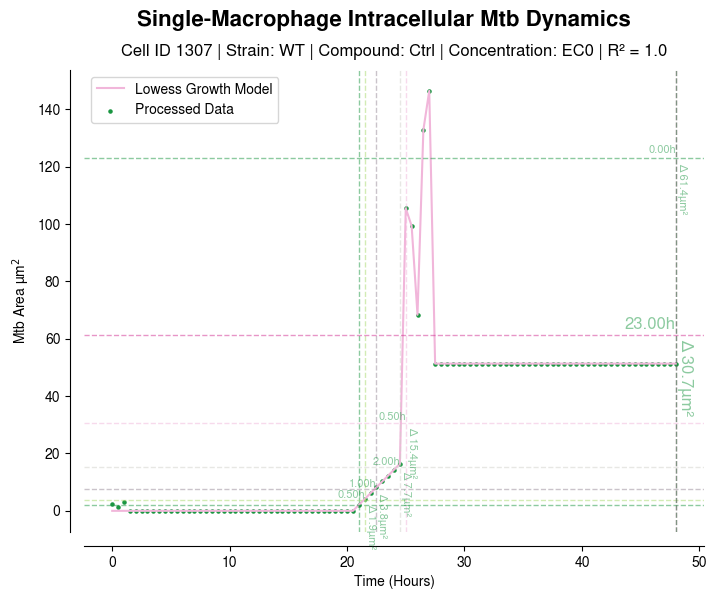

In [20]:
ID = 1307
plot(ID, df)

In [21]:
scale = (1,0.149,0.149)

  0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

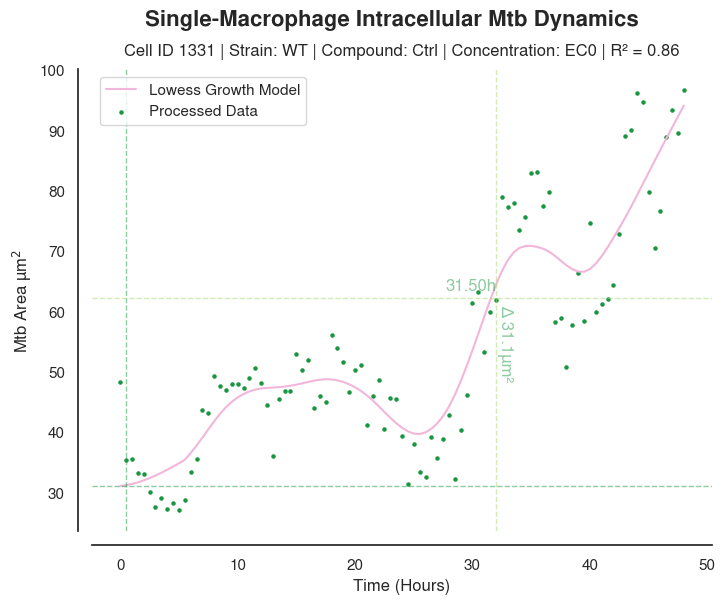

ID 1331 marked as 'Transfer'.
DataFrame saved out
ID 1331 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

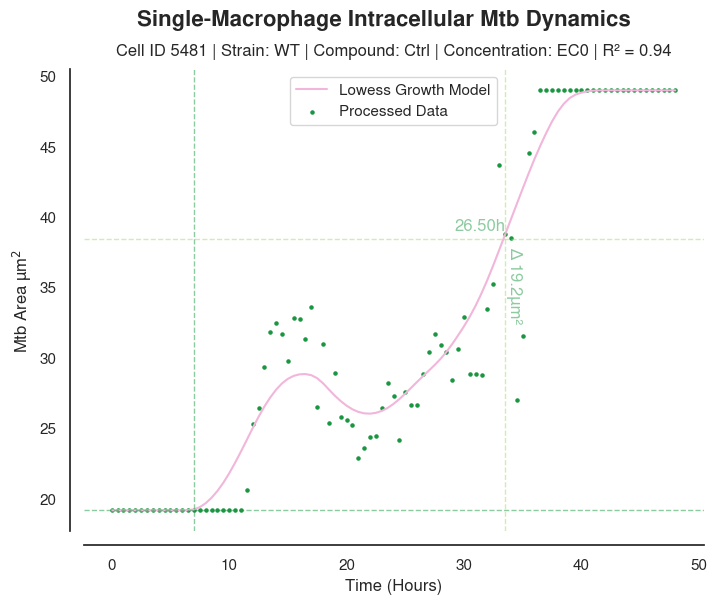

ID 5481 marked as 'Transfer'.
DataFrame saved out
ID 5481 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

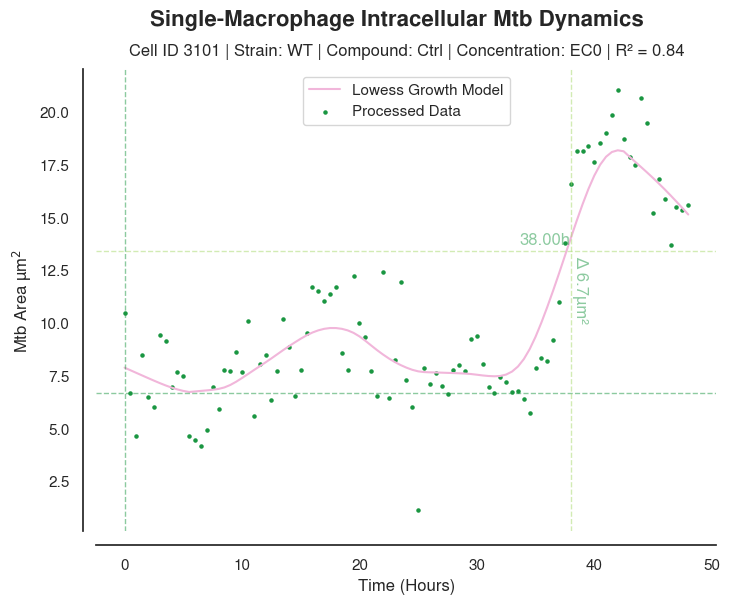

ID 3101 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/89 [00:00<?, ?it/s]

  0%|          | 0/89 [00:00<?, ?it/s]

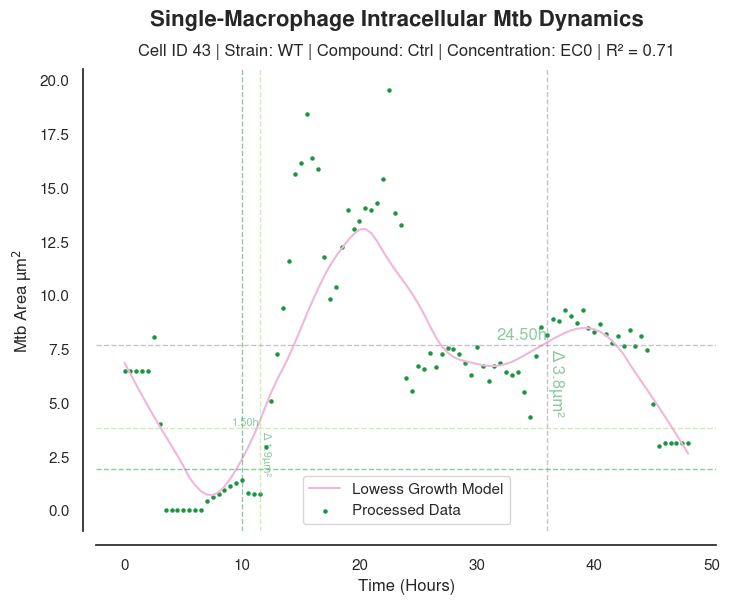

ID 43 marked as 'Transfer'.
DataFrame saved out


  0%|          | 0/85 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

No obvious growth for ID 1295


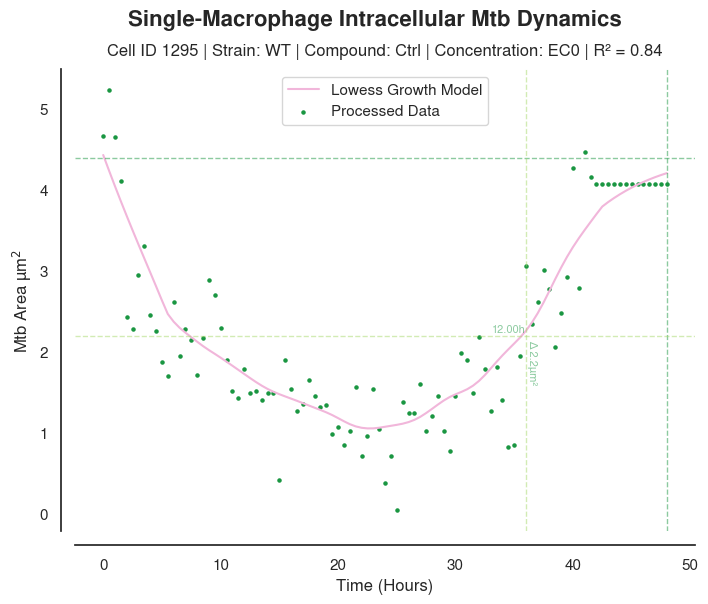

ID 1295 marked as 'Uptake'.
DataFrame saved out


  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

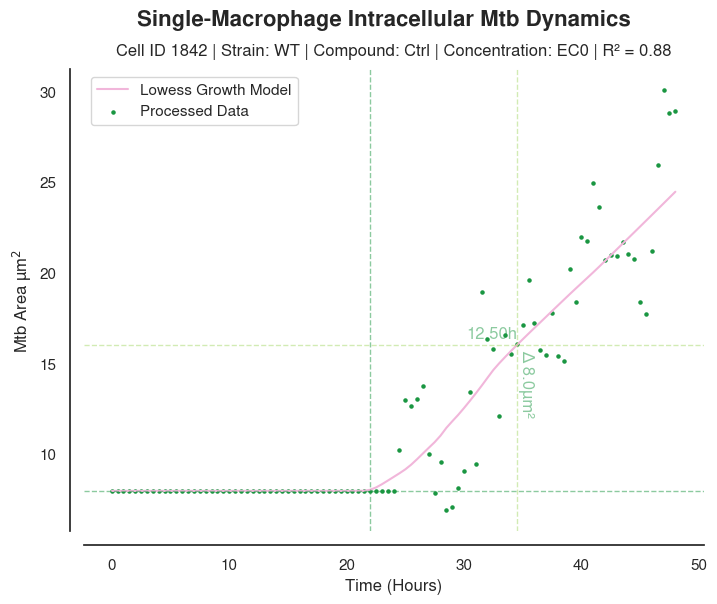

ID 1842 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

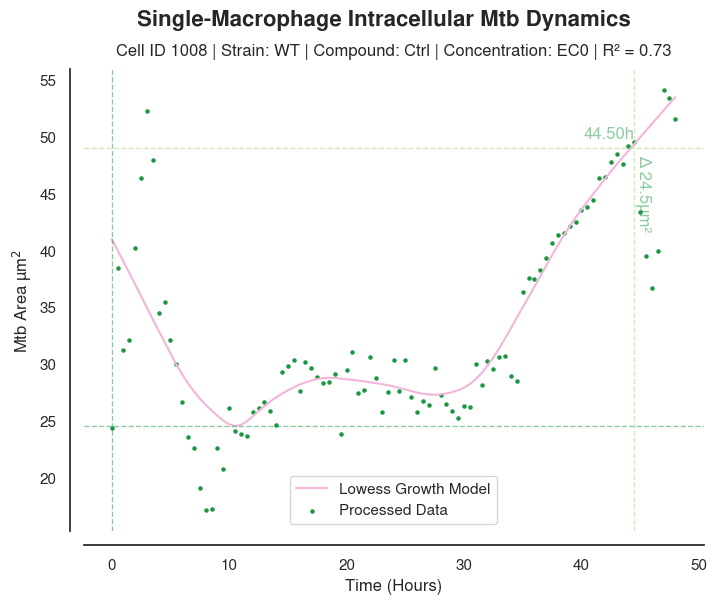

ID 1008 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

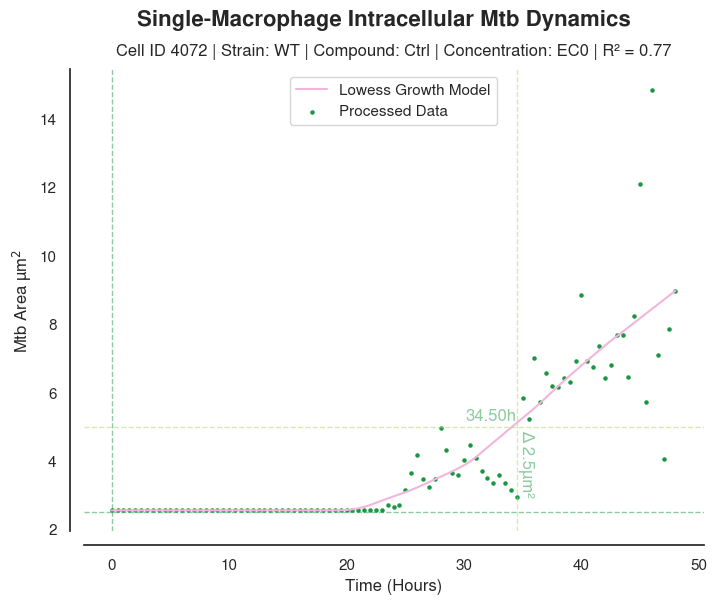

ID 4072 marked as 'Transfer'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

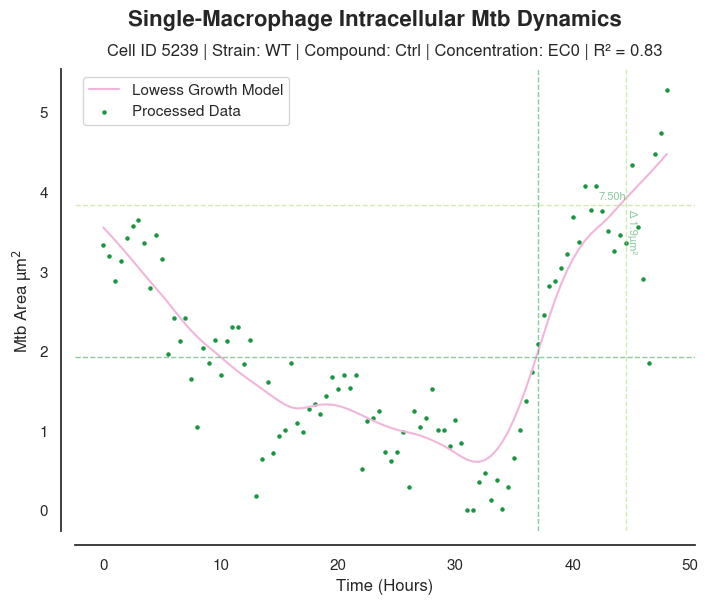

ID 5239 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

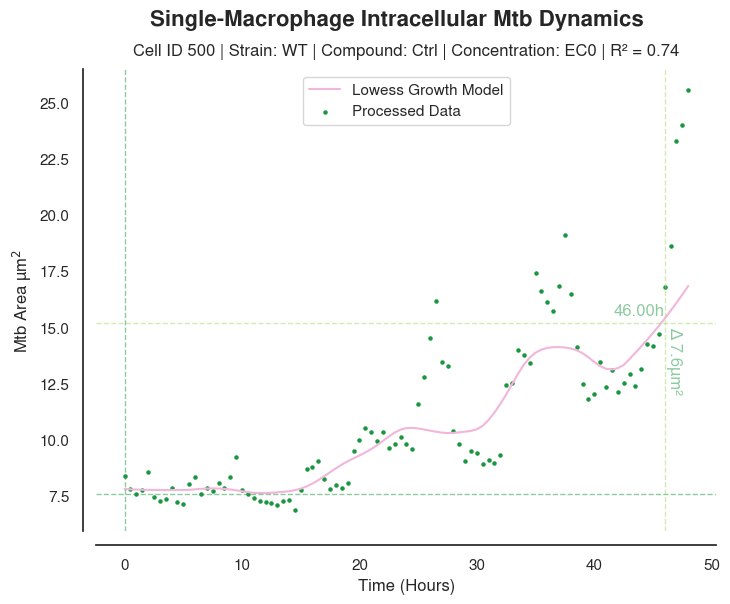

ID 500 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/66 [00:00<?, ?it/s]

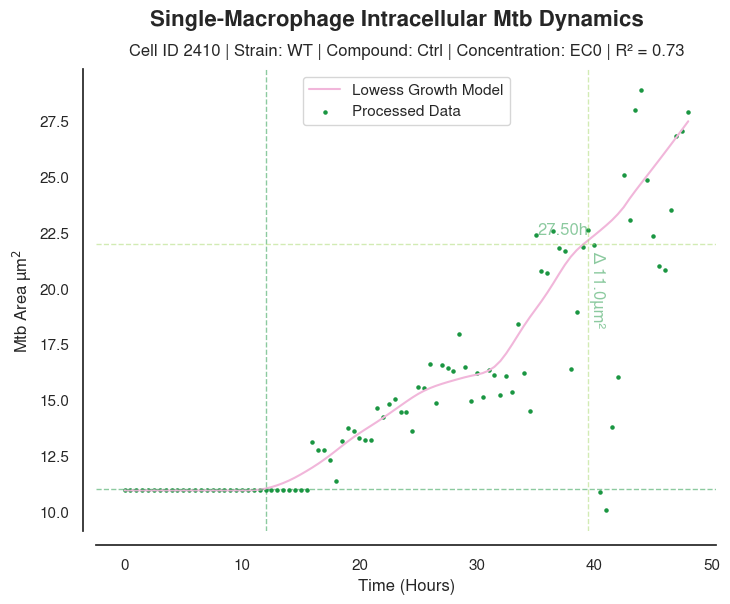

ID 2410 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

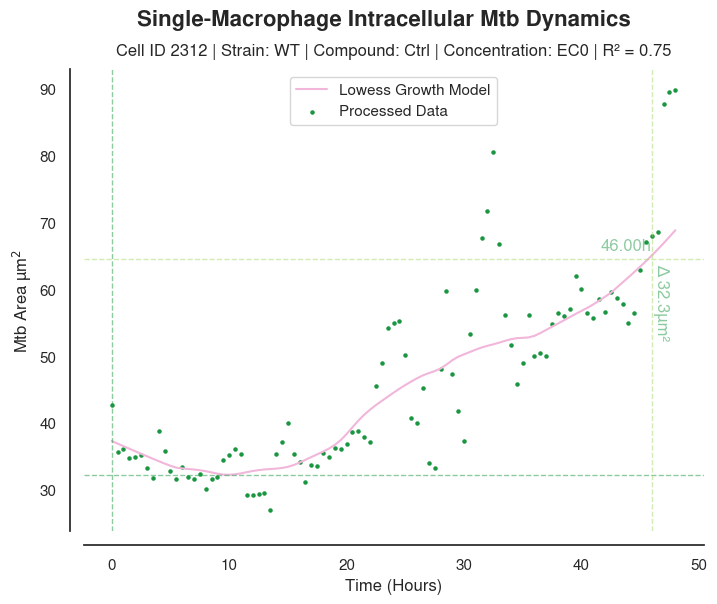

ID 2312 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

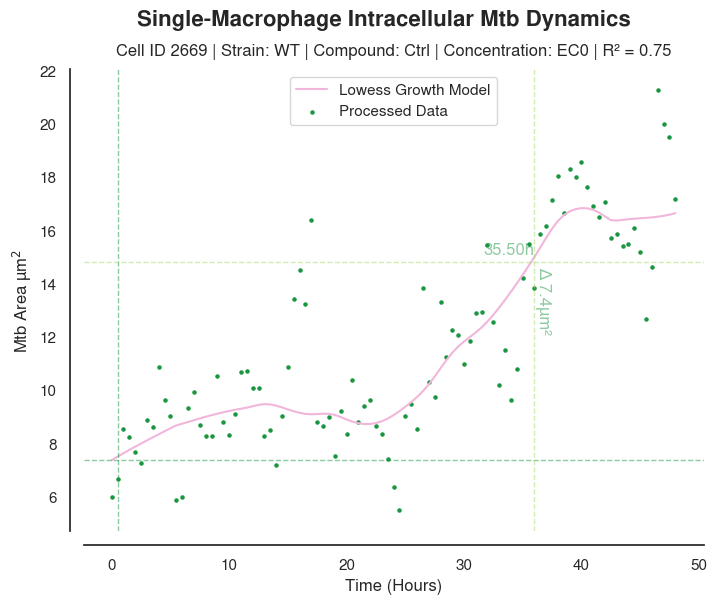

ID 2669 marked as 'Transfer'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

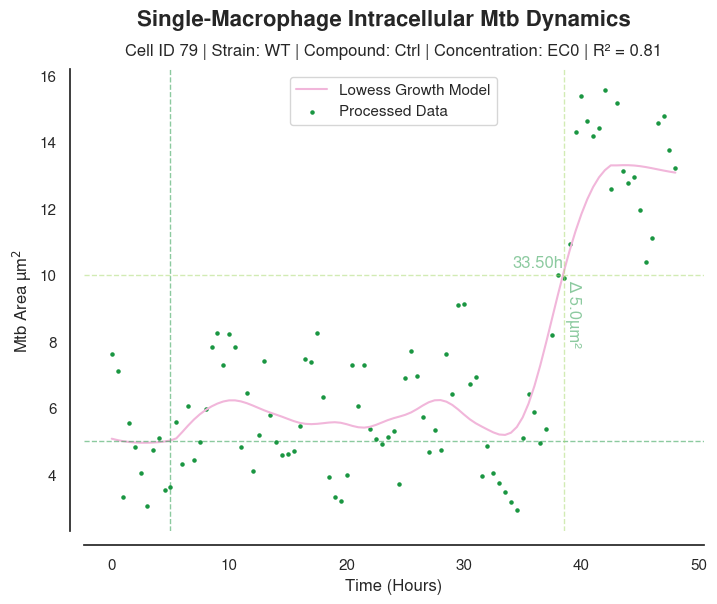

ID 79 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

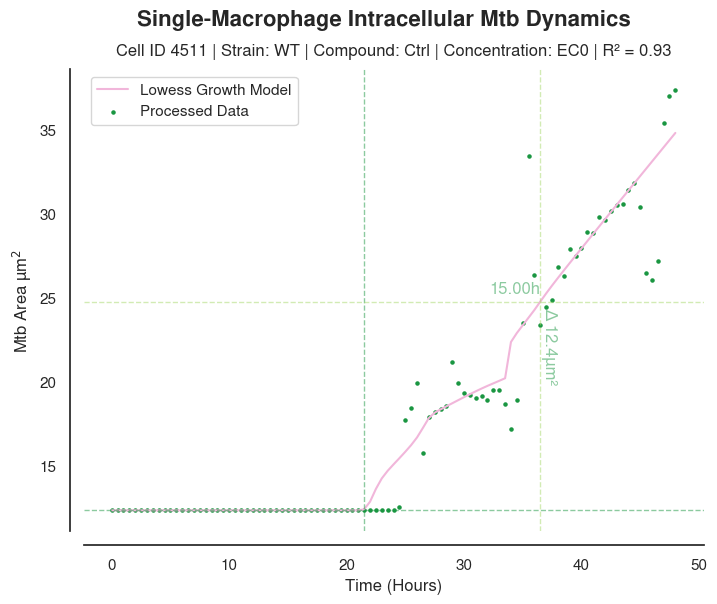

ID 4511 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

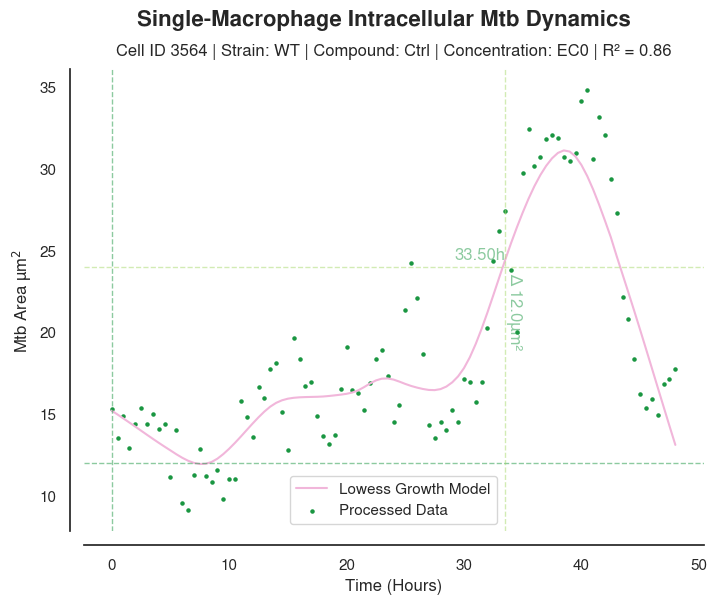

ID 3564 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

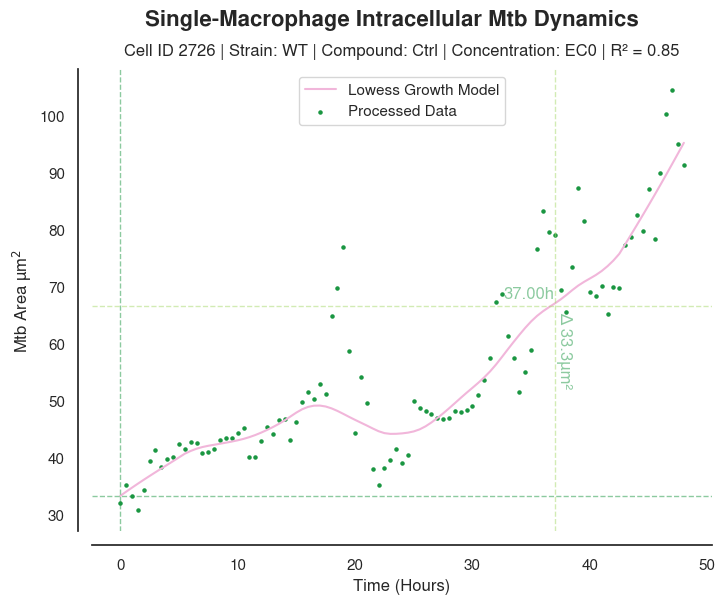

ID 2726 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

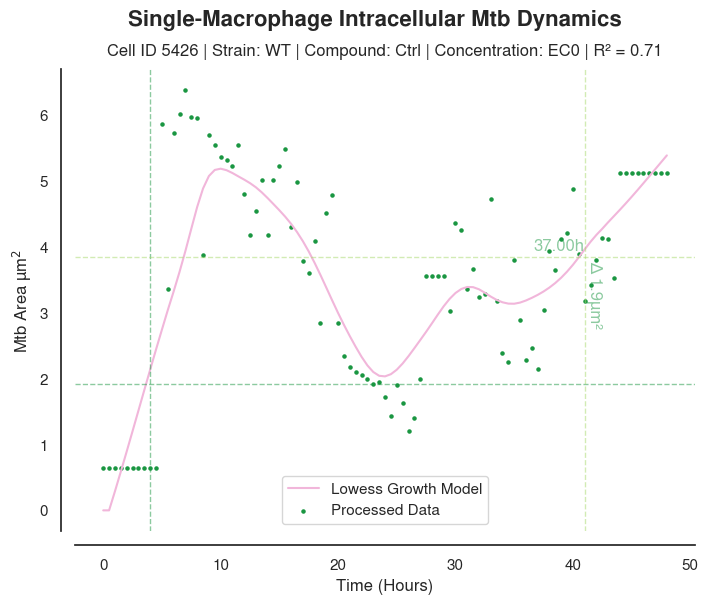

ID 5426 marked as 'Uptake'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

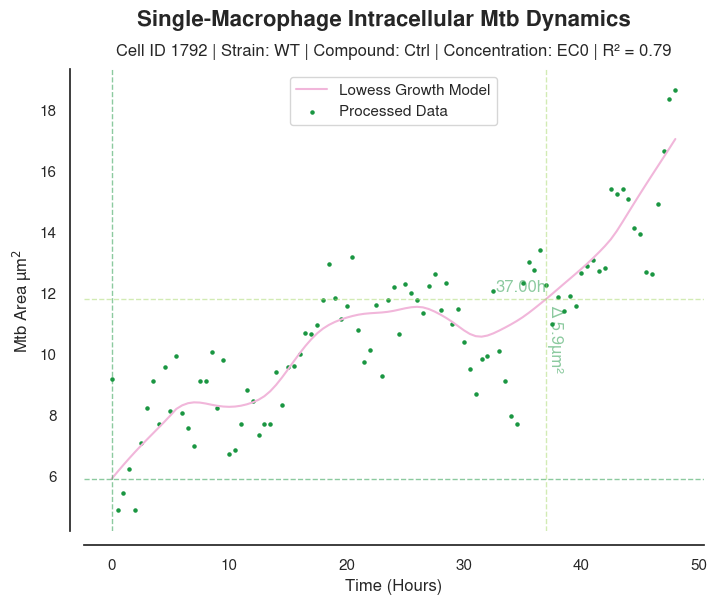

ID 1792 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

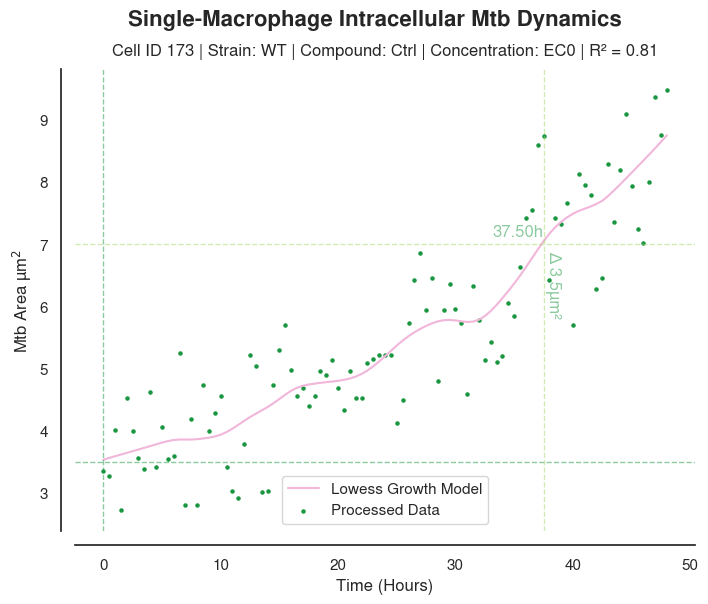

ID 173 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

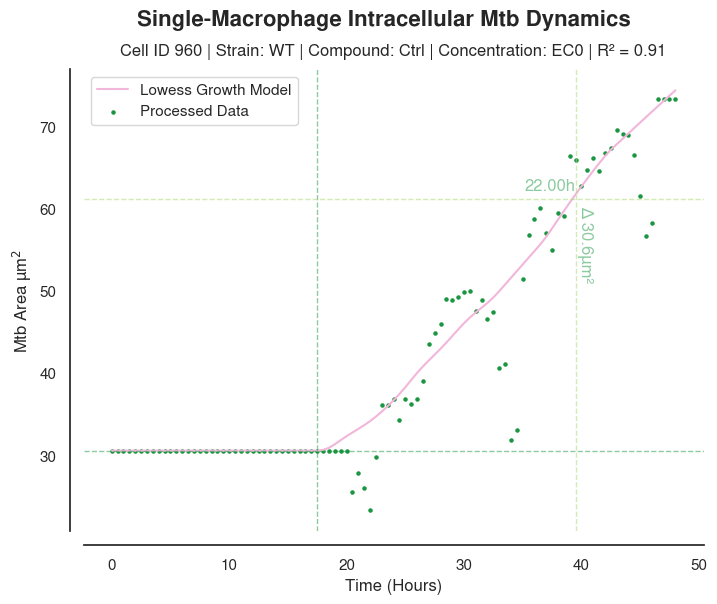

ID 960 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

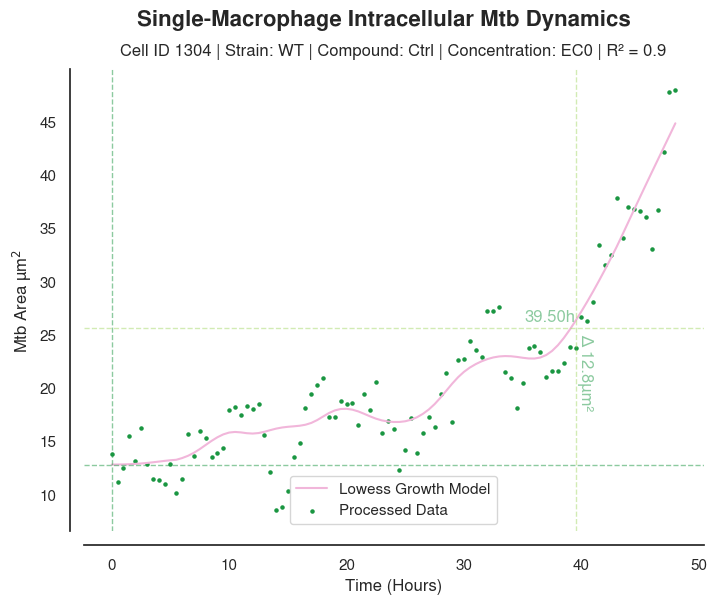

ID 1304 marked as 'Growth'.
DataFrame saved out


  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

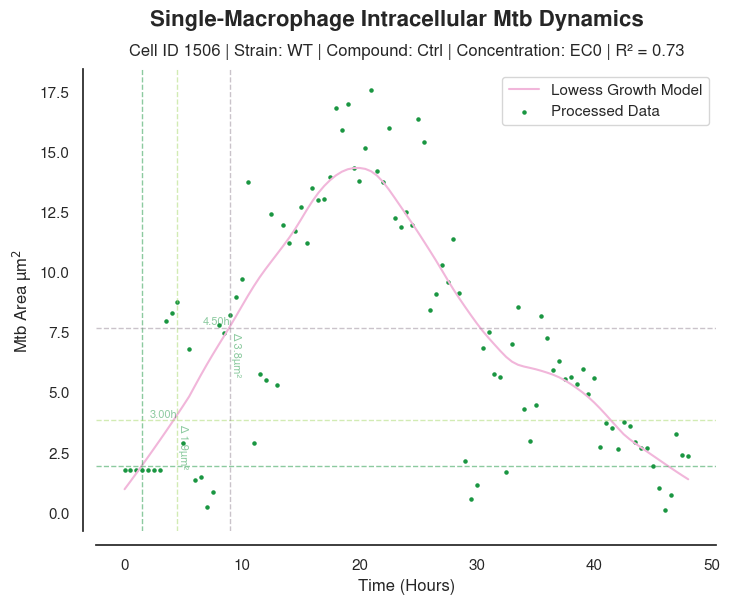

ID 1506 marked as 'Transfer'.
DataFrame saved out


  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

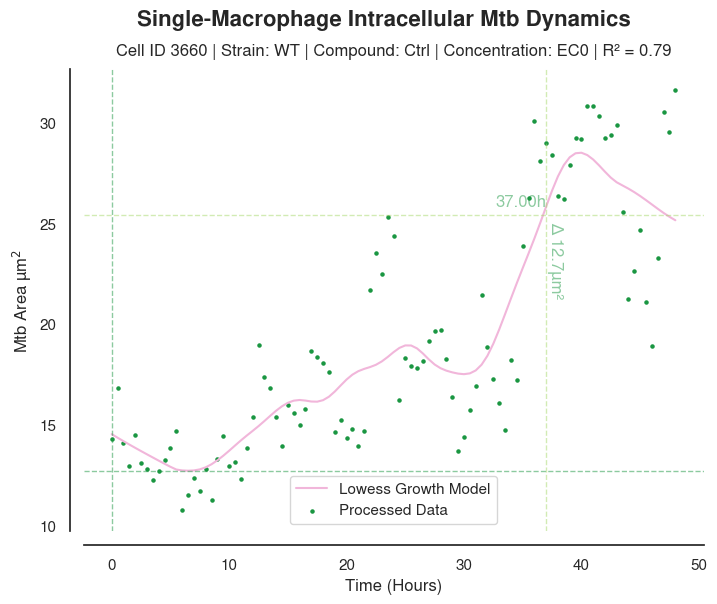

ID 3660 marked as 'Growth'.
DataFrame saved out
Rendering frames...



  0%|                                                                                          | 0/151 [00:00<?, ?it/s]IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (803, 933) to (816, 944) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).

100%|████████████████████████████████████████████████████████████████████████████████| 151/151 [00:12<00:00, 12.41it/s]


In [29]:
for ID in tqdm(ordered_ids):
    val = df[df['ID'] == ID]['mtb_origin'].iloc[0]
    if not pd.isna(val):
        print(f'Already classified ID: {ID} as {val}')
        continue
    # build slices around this ID
    slices, offsets = compute_roi_slices_tczyx(
        df, ID, images,
        pad_xy=200,
        keep_full_z=True   # <- keep all 25 Z planes
        # or keep_full_z=False, z_fixed=12, pad_z=2 to keep a small Z slab
    )
    
    # dask-lazy crops
    img_crop, msk_crop = crop_images_masks_tczyx(images, masks, slices)
    img_crop = timed_compute(img_crop)
    msk_crop = timed_compute(msk_crop)
    viewer = napari.Viewer(title=f'inspecting dts for ID {ID}')
    viewer.add_image(img_crop, channel_axis=1, scale=scale)
    viewer.add_labels(msk_crop, visible=False, scale=scale)
    viewer.bind_key('t', mark_transfer)
    viewer.bind_key('u', mark_uptake)
    viewer.bind_key('j', mark_junk)
    viewer.bind_key('s', save_df)
    viewer.bind_key('g', mark_growth)
    plot(ID, df)
    viewer.show(block=True)
    plt.close()

In [ ]:
print()

# 3190 lamellapodia neighbour nearby

other cells to check:
1. 2978
2. 6014
3. 7380 - edge?
4. 4824 - edge
5. 1735, 7716 - growth???
6. 883 - needs to reset dt
7. 352 - need to reset dt
8. 402 - need to reset dt
9. 381 - need to reset dt?
10. 1861 - need to reset dt
11. 146 - need to recalculate dt
12. 132 - need to recalculate dt
13. 4221 - need to recalculate dt?
14. 1242 - need to recalculate dt?
15. 1128 - need to recalculate dt, or at least remove 0hr
16. 4141 - hm growth
17. 2167 - reinspect
18. 3956 - example of the necessity of 3D imaging
19. 2669 - vampiric cell
    

### Prelim results

/tmp/ipykernel_225084/2742756742.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_225084/2742756742.py:63: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_225084/2742756742.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


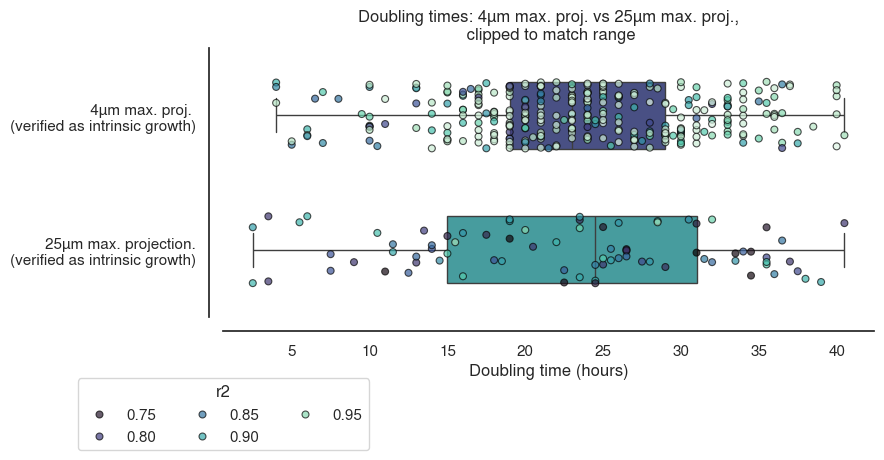

In [34]:
subset_df = (
    df.drop_duplicates(subset="ID")
      .dropna(subset=["Doubling Times"])
      .explode("Doubling Times")
)

subset_df = subset_df[
    # subset_df[id_key].isin(largest_IDs) &
    (subset_df["Doubling Times"] > 0) &
    (subset_df["r2"] >= 0.7)
].copy()

subset_df = subset_df[
    (subset_df["mtb_origin"] == 'Growth')
].copy()

subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)


# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

combo = combo[combo['Doubling Times'] > 0].copy()

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)


plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n(verified as intrinsic growth)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\n clipped to match range")
ax.legend(
    bbox_to_anchor=(0., -0.2),
    loc="upper center",
    ncol=3,   # spread across columns
    frameon=True, 
    title='r2'
)
plt.tight_layout()


In [42]:
df.explode("Doubling Times")

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times,mtb_origin
0,0,1,24,866.0,6511.0,18900.0,0.0,817.0,3.0,3.0,0.0,0.0,0.000000,0.0,0.000000,1.000000,"[1.92, 3.84, 7.68, 15.36]",1.0,Transfer
0,0,1,24,866.0,6511.0,18900.0,0.0,817.0,3.0,3.0,0.0,0.0,0.000000,0.0,0.000000,1.000000,"[1.92, 3.84, 7.68, 15.36]",0.5,Transfer
0,0,1,24,866.0,6511.0,18900.0,0.0,817.0,3.0,3.0,0.0,0.0,0.000000,0.0,0.000000,1.000000,"[1.92, 3.84, 7.68, 15.36]",8.0,Transfer
1,0,6,24,525.0,4880.0,17250.0,0.0,755.0,3.0,3.0,0.0,0.0,0.000000,0.0,0.000000,0.804189,NaN,NaN,None
2,0,9,22,7490.0,1929.0,18000.0,0.0,64.0,3.0,3.0,0.0,0.0,0.000000,0.0,0.144179,0.247361,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130364,96,8597,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,3.195658,48.0,3.201369,0.584448,NaN,NaN,None
130365,96,8600,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.938153,"[1.92, 3.84, 7.68]",-2.5,None
130365,96,8600,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.938153,"[1.92, 3.84, 7.68]",-16.0,None
130366,96,8617,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.850124,"[1.92, 3.84]",-5.5,None


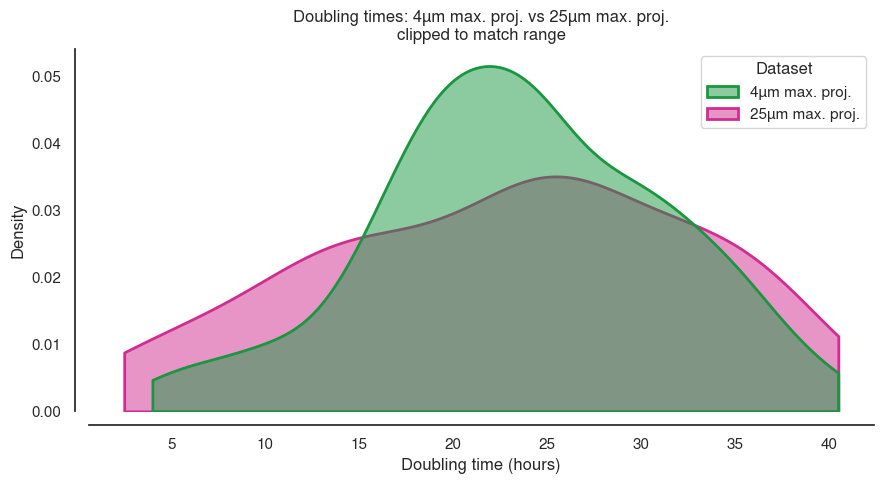

In [38]:
plt.figure(figsize=(9, 5))

# distinct, high-contrast colours
palette = {
    "4µm max. proj.": "#1a9641",   # teal-green
    "25µm max. proj.": "#d02c91",  # orange
}

xmax = a["Doubling Times"].max()

sns.kdeplot(
    data=combo,
    x="Doubling Times",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.5,         # adjust visibility
    linewidth=2,       # darker outlines
    clip=(0, xmax),
    cut=0,
    palette=palette
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")
plt.ylabel("Density")
plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj.\nclipped to match range")
# plt.legend(
#     title="Dataset",
#     frameon=True,
#     loc="upper right",
#     facecolor="white"
# )
plt.tight_layout()


In [1]:
# 3190 lamellapodia neighbour nearby
notes = """
other cells to check:
1. 2978
2. 6014
3. 7380 - edge?
4. 4824 - edge
5. 1735, 7716 - growth???
6. 883 - needs to reset dt
7. 352 - need to reset dt
8. 402 - need to reset dt
9. 381 - need to reset dt?
10. 1861 - need to reset dt
11. 146 - need to recalculate dt
12. 132 - need to recalculate dt
13. 4221 - need to recalculate dt?
14. 1242 - need to recalculate dt?
15. 1128 - need to recalculate dt, or at least remove 0hr
16. 4141 - hm growth
17. 2167 - reinspect
18. 3956 - example of the necessity of 3D imaging
19. 2669 - vampiric cell
"""

In [9]:
import re

# 1) Grab the text after each enumerator like "1."
lines = re.findall(r'^\s*\d+\.\s*(.*)$', notes, flags=re.MULTILINE)

# 2) From those lines, extract all pure numeric IDs (handles "1735, 7716")
ids = [m for line in lines for m in re.findall(r'\b\d+\b', line)]

# (optional) de-dupe while keeping order, and cast to int
ids_unique = list(dict.fromkeys(map(int, ids)))

print(ids_unique)


[2978, 6014, 7380, 4824, 1735, 7716, 883, 352, 402, 381, 1861, 146, 132, 4221, 1242, 1128, 4141, 2167, 3956, 2669]


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

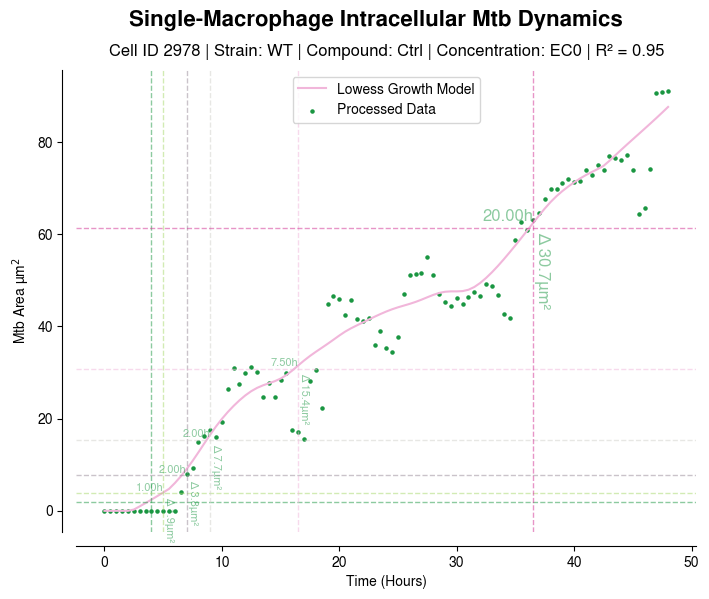

In [24]:
for ID in tqdm(ids_unique):
    val = df[df['ID'] == ID]['mtb_origin'].iloc[0]
    # if not pd.isna(val):
    #     print(f'Already classified ID: {ID} as {val}')
    #     continue
    # build slices around this ID
    slices, offsets = compute_roi_slices_tczyx(
        df, ID, images,
        pad_xy=400,
        keep_full_z=True   # <- keep all 25 Z planes
        # or keep_full_z=False, z_fixed=12, pad_z=2 to keep a small Z slab
    )
    
    # dask-lazy crops
    img_crop, msk_crop = crop_images_masks_tczyx(images, masks, slices)
    img_crop = timed_compute(img_crop)
    msk_crop = timed_compute(msk_crop)
    viewer = napari.Viewer(title=f'inspecting dts for ID {ID}')
    viewer.add_image(img_crop, channel_axis=1, scale=scale)
    viewer.add_labels(msk_crop, visible=False, scale=scale)
    napari_tracks = adjust_tracks_fixed_z(tracks, ID, slices)[['ID', 't', 'z', 'y', 'x']].values
    viewer.add_tracks(napari_tracks, scale=scale)
    # viewer.bind_key('t', mark_transfer)
    # viewer.bind_key('u', mark_uptake)
    # viewer.bind_key('j', mark_junk)
    # viewer.bind_key('s', save_df)
    # viewer.bind_key('g', mark_growth)
    plot(ID, df)
    break
    # viewer.show(block=True)
    # plt.close()

In [52]:
track_scale = (1,0.149,0.149)

In [53]:
napari_tracks

array([[2.978e+03, 0.000e+00, 1.200e+01, 4.280e+02, 4.000e+02],
       [2.978e+03, 1.000e+00, 1.200e+01, 4.280e+02, 4.090e+02],
       [2.978e+03, 2.000e+00, 1.200e+01, 4.480e+02, 4.240e+02],
       [2.978e+03, 3.000e+00, 1.200e+01, 4.530e+02, 4.300e+02],
       [2.978e+03, 4.000e+00, 1.200e+01, 4.600e+02, 4.380e+02],
       [2.978e+03, 5.000e+00, 1.200e+01, 4.520e+02, 4.480e+02],
       [2.978e+03, 6.000e+00, 1.200e+01, 4.820e+02, 4.660e+02],
       [2.978e+03, 7.000e+00, 1.200e+01, 4.870e+02, 4.780e+02],
       [2.978e+03, 8.000e+00, 1.200e+01, 4.880e+02, 4.800e+02],
       [2.978e+03, 9.000e+00, 1.200e+01, 4.690e+02, 4.970e+02],
       [2.978e+03, 1.000e+01, 1.200e+01, 4.510e+02, 4.970e+02],
       [2.978e+03, 1.100e+01, 1.200e+01, 4.370e+02, 4.880e+02],
       [2.978e+03, 1.200e+01, 1.200e+01, 4.420e+02, 4.920e+02],
       [2.978e+03, 1.300e+01, 1.200e+01, 4.410e+02, 4.910e+02],
       [2.978e+03, 1.400e+01, 1.200e+01, 4.370e+02, 4.910e+02],
       [2.978e+03, 1.500e+01, 1.200e+01,

<Tracks layer 'napari_tracks [1]' at 0x7e2d3add9f50>